# Stochastic evolution of a colony of B cells in dimension 1
Compare with least action

In [13]:
import matplotlib.pyplot as plt
from __future__ import annotations
import numpy as np
from numpy.random import default_rng

In [14]:
# """
# Germinal‑centre B‑cell maturation with multiple antigens
# ========================================================

# • State of each cycling B‑cell: h ∈ ℝ^{N_h} (residue binding‑energy vector)
# • Antigens:            S_mat ∈ {‑1, +1}^{N_h × n_A}
#                        ε_v(h) = Σ_i s_{iv} h_i    for every antigen v
# • One round:           duplication → SHM → Ag‑gate → T‑gate → differentiation
# • Output:              `history[step]` is a NumPy array of shape
#                        (n_cells_alive_that_step, N_h) with the h‑vectors

# The implementation below follows exactly the gates used in your FP solver.
# """



# # --------------------- biological / model parameters -------------------
# mu_M=-0.8
# sigma_M=1.09
# S_mat=None                      # shape (N_h, n_A) : s_{k,v} ∈ {±1}





# mu=0.001*3*40
# p_sil=0.5*(mu)+(1-mu)
# p_let=0.3*(mu)
# p_aa=0.2*(mu)
# E_a=np.log(40)                       
# T=140
# kBT=1                       # thermal factor
# N_i=2500  
# N_max=2500 
# mu_i=0.0 
# sigma_i=0.001
# p_diff=0.10
# c=170# 800, 1120, 920, 510




# # -------------------------- helper functions ---------------------------
# def energies(pop: np.ndarray, S_mat: np.ndarray) -> np.ndarray:
#     """
#     Compute energies for every cell and every antigen.

#     Parameters
#     ----------
#     pop   : (N_cells, N_h) ndarray
#     S_mat : (N_h, n_A)     ndarray

#     Returns
#     -------
#     eps : (N_cells, n_A) ndarray   with eps[c, v] = ε_v(h_c)
#     """
#     return pop @ S_mat                     # broadcasting handles dot‑product

# def P_Ag(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
#     """
#     Antigen‑binding survival gate   P_Ag(h)

#     eps   : (N_cells, n_A) energies
#     C_vec : (n_A,)        antigen concentrations at current round
#     """
#     exp_term   = np.exp((eps - E_a) / kBT)         # same as FP code
#     numer      = (exp_term * C_vec).sum(axis=1)    # Σ_v C_v e^{(ε_v - E_a)/kT}
#     return numer / (1.0 + numer)

# def P_T(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
#     """
#     T‑cell‑help survival gate   P_T(h | pop)

#     eps   : (N_cells, n_A) energies *after* Ag selection
#     """
#     C_tot      = C_vec.sum()
#     eE         = np.exp(eps / kBT)                 # e^{ε_v/kT}
#     Phi        = (eE * C_vec).sum(axis=1)          # Σ_v C_v e^{ε_v/kT}
#     Phi_bar    = Phi.mean()                       # ⟨Φ⟩_pop
#     return Phi / (Phi + Phi_bar / C_tot)

# # ----------------------- one maturation round --------------------------
# def gc_round(pop: np.ndarray,
#              S_mat: np.ndarray,
#              C_vec: np.ndarray,
#              rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
#     """
#     Advance the cycling population by one GC round.

#     Returns
#     -------
#     pop_next : ndarray   surviving cycling cells
#     mem      : ndarray   newly differentiated memory / plasma cells
#     """
#     # 1 Duplication ------------------------------------------------------
#     pop = np.repeat(pop, 2, axis=0)               # each cell divides

#     # 2 Somatic hyper‑mutation ------------------------------------------
#     N_cells   = pop.shape[0]
#     fate      = rng.choice(
#         ["let", "aa", "sil"], size=N_cells,
#         p=[p_let, p_aa, p_sil]
#     )

#     alive_mask = fate != "let"
#     aa_mask    = fate == "aa"
#     n_aa       = aa_mask.sum()

#     if n_aa:
#         idx_sites   = rng.integers(0, pop.shape[1], size=n_aa)
#         delta_h     = rng.normal(mu_M, sigma_M, size=n_aa)
#         pop[aa_mask, idx_sites] = pop[aa_mask, idx_sites] + delta_h

#     pop = pop[alive_mask]                         # drop lethal daughters
#     if pop.size == 0:
#         return pop, np.empty((0, pop.shape[1]))

#     # 3 Antigen‑binding gate --------------------------------------------
#     eps      = energies(pop, S_mat)
#     P_ag     = P_Ag(eps, C_vec)
#     survive  = rng.random(size=P_ag.size) < P_ag
#     pop      = pop[survive];  eps = eps[survive]
#     if pop.size == 0:
#         return pop, np.empty((0, S_mat.shape[0]))

#     # 4 T‑cell‑help gate -------------------------------------------------
#     P_t      = P_T(eps, C_vec)
#     survive  = rng.random(size=P_t.size) < P_t
#     pop      = pop[survive]
#     if pop.size == 0:
#         return pop, np.empty((0, S_mat.shape[0]))

#     # 5 Differentiation --------------------------------------------------
#     diff_mask = rng.random(size=pop.shape[0]) < p_diff
#     mem_cells = pop[diff_mask]
#     pop       = pop[~diff_mask]

#     return pop, mem_cells

# # ---------------------- full GC simulation driver ----------------------
# def simulate_gc_history(rounds: int,
#                         S_mat: np.ndarray,
#                         N_init: int = N_i,
#                         N_max: int  = N_max,
#                         C_schedule = lambda r: np.array([c]),
#                         mu_init: float = mu_i,
#                         sigma_init: float = sigma_i,
#                         seed: int | None = None
#                        ) -> list[np.ndarray]:
#     """
#     Simulate `rounds` germinal‑centre cycles and return the full history.

#     Returns
#     -------
#     history : list of ndarray
#         history[t] has shape (n_cells_alive_at_t, N_h)
#     """
#     rng  = default_rng(seed)
#     N_h  = S_mat.shape[0]

#     # Gaussian initial repertoire
#     pop = rng.normal(mu_init, sigma_init, size=(N_init, N_h))
#     history: list[np.ndarray] = [pop.copy()]

#     for r in range(rounds):
#         C_vec = np.asarray(C_schedule(), dtype=float)   # shape (n_A,)
#         pop, _mem_cells = gc_round(pop, S_mat, C_vec, rng)

#         # population cap
#         if pop.shape[0] > N_max:
#             keep_idx = rng.choice(pop.shape[0], N_max, replace=False)
#             pop = pop[keep_idx]

#         history.append(pop.copy())

#     return history




In [15]:
# S_mat = np.array([[1]])

# # Antigen concentration decays exponentially over rounds
# def C_schedule():
#     return np.array([c]) 

# history = simulate_gc_history(
#     rounds   = T,
#     S_mat    = S_mat,
#     N_init   = N_i,
#     N_max    = N_max,
#     C_schedule = C_schedule,
#     seed     = 0
# )

# # `history` is the requested list‑of‑arrays result
# print(f"Rounds simulated: {len(history)-1}")
# for t, pop in enumerate(history[:]):       # first few steps
#     print(f"t={t:02d}  cycling cells={pop.shape[0]}")

In [16]:
# import matplotlib.pyplot as plt

# # Extract (time step, h1) pairs
# time_points = []
# h1_values = []

# for t, pop in enumerate(history):
#     time_points.extend([t] * pop.shape[0])  # replicate time index
#     h1_values.extend(pop[:, 0])             # extract h1 values

# # Create the 2D histogram (density plot)
# import numpy as np
# import matplotlib.pyplot as plt

# # --- parameters and raw data ------------------------------------------
# t_clip = 50
# rounds = np.asarray(time_points)
# h_vals = np.asarray(h1_values)

# # --- define bins ------------------------------------------------------
# n_rounds = len(history)
# n_hbins  = 100
# round_bins = np.linspace(rounds.min(), rounds.max(), n_rounds + 1)
# h_bins    = np.linspace(h_vals.min(), h_vals.max(), n_hbins + 1)

# # --- compute 2D histogram manually ------------------------------------
# H, xedges, yedges = np.histogram2d(rounds, h_vals, bins=[round_bins, h_bins])

# # --- clip color scale using t ≥ t_clip --------------------------------
# idx_clip = np.searchsorted(xedges, t_clip)
# vmax_clip = H[idx_clip:].max()

# # --- plot using imshow ------------------------------------------------
# plt.figure(figsize=(8, 5))
# im = plt.imshow(H.T, origin="lower", aspect="auto",
#                 extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
#                 cmap="Greys_r", vmin=0.0, vmax=vmax_clip)
# plt.xlabel("Round")
# plt.ylabel(r"$h_1$")
# plt.title(r"Density of B-cells in $h_1$ over GC rounds")
# plt.colorbar(im, label="Density")
# plt.tight_layout()
# plt.ylim(-2.5, 10)
# plt.show()




# Lineages bis

In [17]:
# import numpy as np
# from numpy.random import default_rng

# # --------------------- biological / model parameters -------------------
# mu_M = -0.8
# sigma_M = 1.09
# S_mat = None  # defined later

# mu = 0.001 * 3 * 40
# p_sil = 0.5 * (mu) + (1 - mu)
# p_let = 0.3 * (mu)
# p_aa = 0.2 * (mu)
# E_a = np.log(40)
# T_steps = 140
# kBT = 1
# N_i = 2500
# N_max = 2500
# mu_i = 0.0
# sigma_i = 0.001
# p_diff = 0.10
# c = 170

# # -------------------------- helper functions ---------------------------
# def energies(pop: np.ndarray, S_mat: np.ndarray) -> np.ndarray:
#     """Compute energies for every cell and every antigen."""
#     return pop @ S_mat

# def P_Ag(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
#     """Antigen-binding survival gate."""
#     exp_term = np.exp((eps - E_a) / kBT)
#     numer = (exp_term * C_vec).sum(axis=1)
#     return numer / (1.0 + numer)

# def P_T(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
#     """T-cell-help survival gate."""
#     C_tot = C_vec.sum()
#     eE = np.exp(eps / kBT)
#     Phi = (eE * C_vec).sum(axis=1)
#     Phi_bar = Phi.mean()
#     if C_tot == 0: return np.zeros_like(Phi)
#     return Phi / (Phi + Phi_bar / C_tot)

# # ----------------------- one maturation round --------------------------
# def gc_round(pop: np.ndarray,
#              ids: np.ndarray,
#              next_uid: int,
#              S_mat: np.ndarray,
#              C_vec: np.ndarray,
#              rng: np.random.Generator):
#     """
#     Advance the cycling population by one GC round, tracking IDs.
    
#     Returns:
#         pop: New population vectors
#         ids: New population IDs
#         parent_ids: The parent ID for each cell in the new population
#         next_uid: Updated global ID counter
#         mem_data: Tuple of (mem_pop, mem_ids, mem_parent_ids)
#     """
#     # 1. Duplication (Tracking Lineage) -------------------------------
#     # Parents become the parent_ids for the next generation
#     n_parents = pop.shape[0]
    
#     # Repeat phenotypes
#     pop = np.repeat(pop, 2, axis=0)
    
#     # The 'ids' of the current step become 'parent_ids' of the next step
#     parent_ids = np.repeat(ids, 2)
    
#     # Generate fresh unique IDs for the new daughter cells
#     ids = np.arange(next_uid, next_uid + 2 * n_parents, dtype=np.int64)
#     next_uid += 2 * n_parents

#     # 2. Somatic hyper-mutation ---------------------------------------
#     N_cells = pop.shape[0]
#     fate = rng.choice(["let", "aa", "sil"], size=N_cells, p=[p_let, p_aa, p_sil])

#     alive_mask = fate != "let"
#     aa_mask = fate == "aa"
#     n_aa = aa_mask.sum()

#     if n_aa:
#         idx_sites = rng.integers(0, pop.shape[1], size=n_aa)
#         delta_h = rng.normal(mu_M, sigma_M, size=n_aa)
#         pop[aa_mask, idx_sites] = pop[aa_mask, idx_sites] + delta_h

#     # Apply lethal filter to all parallel arrays
#     pop = pop[alive_mask]
#     ids = ids[alive_mask]
#     parent_ids = parent_ids[alive_mask]
    
#     if pop.size == 0:
#         return pop, ids, parent_ids, next_uid, (np.empty((0, pop.shape[1])), np.array([]), np.array([]))

#     # 3. Antigen-binding gate -----------------------------------------
#     eps = energies(pop, S_mat)
#     P_ag = P_Ag(eps, C_vec)
#     survive = rng.random(size=P_ag.size) < P_ag
    
#     pop = pop[survive]
#     ids = ids[survive]
#     parent_ids = parent_ids[survive]
#     eps = eps[survive]
    
#     if pop.size == 0:
#         return pop, ids, parent_ids, next_uid, (np.empty((0, S_mat.shape[0])), np.array([]), np.array([]))

#     # 4. T-cell-help gate ---------------------------------------------
#     P_t = P_T(eps, C_vec)
#     survive = rng.random(size=P_t.size) < P_t
    
#     pop = pop[survive]
#     ids = ids[survive]
#     parent_ids = parent_ids[survive]
    
#     if pop.size == 0:
#         return pop, ids, parent_ids, next_uid, (np.empty((0, S_mat.shape[0])), np.array([]), np.array([]))

#     # 5. Differentiation ----------------------------------------------
#     diff_mask = rng.random(size=pop.shape[0]) < p_diff
    
#     # Extract memory cells
#     mem_pop = pop[diff_mask]
#     mem_ids = ids[diff_mask]
#     mem_parent_ids = parent_ids[diff_mask]
    
#     # Keep cycling cells
#     pop = pop[~diff_mask]
#     ids = ids[~diff_mask]
#     parent_ids = parent_ids[~diff_mask]

#     return pop, ids, parent_ids, next_uid, (mem_pop, mem_ids, mem_parent_ids)

# # ---------------------- full GC simulation driver ----------------------
# def simulate_gc_with_ancestry(rounds: int,
#                               S_mat: np.ndarray,
#                               N_init: int = N_i,
#                               N_max: int = N_max,
#                               C_schedule = lambda r: np.array([c]),
#                               mu_init: float = mu_i,
#                               sigma_init: float = sigma_i,
#                               seed: int | None = None):
#     """
#     Simulates GC and stores ID and Parent_ID to reconstruction lineages.
#     """
#     rng = default_rng(seed)
#     N_h = S_mat.shape[0]

#     # Initialize
#     pop = rng.normal(mu_init, sigma_init, size=(N_init, N_h))
    
#     # Assign initial IDs (0 to N_init-1)
#     # Parent ID -1 indicates "Founder" (start of simulation)
#     ids = np.arange(N_init, dtype=np.int64)
#     parent_ids = np.full(N_init, -1, dtype=np.int64)
#     next_uid = N_init

#     # History will store dictionaries now
#     history = []
    
#     # Store state 0
#     history.append({
#         'pop': pop.copy(),
#         'ids': ids.copy(),
#         'parent_ids': parent_ids.copy()
#     })

#     for r in range(rounds):
#         C_vec = np.asarray(C_schedule(), dtype=float)
        
#         # Run round
#         pop, ids, parent_ids, next_uid, _mem = gc_round(
#             pop, ids, next_uid, S_mat, C_vec, rng
#         )

#         # Population Cap (Resampling)
#         if pop.shape[0] > N_max:
#             keep_idx = rng.choice(pop.shape[0], N_max, replace=False)
#             pop = pop[keep_idx]
#             ids = ids[keep_idx]
#             parent_ids = parent_ids[keep_idx]

#         history.append({
#             'pop': pop.copy(),
#             'ids': ids.copy(),
#             'parent_ids': parent_ids.copy()
#         })
        
#         if pop.shape[0] == 0:
#             break

#     return history

# # ---------------------- Lineage Reconstruction ----------------------
# def trace_lineages(history, target_indices_at_end):
#     """
#     Reconstructs trajectories for specific cells found in the last step.
    
#     Parameters
#     ----------
#     history : list of dicts
#         The output from simulate_gc_with_ancestry.
#     target_indices_at_end : array-like
#         Indices in the *last* history frame of the cells you want to trace.
        
#     Returns
#     -------
#     trajectories : list of numpy arrays
#         A list where each element is an array of shape (T+1, N_h)
#         representing the path of a single lineage.
#     """
#     if not history:
#         return []

#     # Get the last frame
#     final_step = len(history) - 1
#     last_frame = history[final_step]
    
#     # These are the IDs we want to trace back
#     current_ids_to_trace = last_frame['ids'][target_indices_at_end]
    
#     # Initialize storage for paths: Dictionary mapping Final_ID -> List of vectors
#     paths = {uid: [] for uid in current_ids_to_trace}
    
#     # Backward pass
#     for t in range(final_step, -1, -1):
#         frame = history[t]
#         frame_ids = frame['ids']
#         frame_pop = frame['pop']
#         frame_parents = frame['parent_ids']
        
#         # Map IDs in this frame to their index for fast lookup
#         # (Using a dict is safer than np.where for sparse lookups, 
#         # though standard np.isin/where works if arrays are sorted)
#         id_to_idx = {uid: i for i, uid in enumerate(frame_ids)}
        
#         next_ids_to_trace = []
        
#         for final_uid, current_tracking_id in zip(current_ids_to_trace, current_ids_to_trace):
#             if current_tracking_id in id_to_idx:
#                 idx = id_to_idx[current_tracking_id]
                
#                 # Record phenotype
#                 phenotype = frame_pop[idx]
#                 paths[final_uid].append(phenotype)
                
#                 # Find parent for next step (going backwards)
#                 parent_id = frame_parents[idx]
#                 if parent_id != -1: # -1 is root
#                     # Update the ID we are looking for in the previous frame
#                     # We store this in a list to keep order aligned with loop
#                     # But actually we just need to update the tracking list after loop
#                     pass 
#             else:
#                 # Lineage might have been lost due to logic error or complexity,
#                 # but usually this means the cell didn't exist in this frame 
#                 # (impossible if logic is correct and we go T -> 0)
#                 pass
        
#         # Update the list of IDs to look for in the next iteration (t-1)
#         # We need to map {final_uid -> parent_id_at_t}
#         new_tracking_list = []
#         for final_uid in list(paths.keys()):
#             # Get the ID we were looking for at time t
#             # The paths are stored [h_T, h_T-1, ...], so current head is last added
#             # But we need the ID mapping.
#             # Let's re-access the frame to get the parent ID.
            
#             # The ID we searched for at time t is:
#             # We can't easily infer it from `paths`, so let's maintain a mapping
#             # current_tracking_map: Final_UID -> Current_UID
#             pass

#     # Let's rewrite the backward loop to be cleaner using a direct map
#     # Map: Final_Unique_ID -> Current_Ancestor_ID
#     active_traces = {uid: uid for uid in current_ids_to_trace}
    
#     # Storage: Final_Unique_ID -> List of h vectors
#     results = {uid: [] for uid in current_ids_to_trace}
    
#     for t in range(final_step, -1, -1):
#         frame = history[t]
        
#         # Create lookup for this frame: ID -> (Index, Parent_ID, Vector)
#         # This is O(N) per frame.
#         frame_lookup = {uid: (i, pid, vec) 
#                        for i, (uid, pid, vec) 
#                        in enumerate(zip(frame['ids'], frame['parent_ids'], frame['pop']))}
        
#         for final_uid, ancestor_id in list(active_traces.items()):
#             if ancestor_id in frame_lookup:
#                 _, parent_id, vector = frame_lookup[ancestor_id]
#                 results[final_uid].append(vector)
                
#                 # Step back: looking for parent in previous frame
#                 if parent_id != -1:
#                     active_traces[final_uid] = parent_id
#                 else:
#                     # Reached root
#                     del active_traces[final_uid]
#             else:
#                 # Should not happen in a unbroken chain
#                 del active_traces[final_uid]
                
#     # Reverse lists to get time 0 -> T
#     trajectories = []
#     for uid in current_ids_to_trace:
#         traj = np.array(results[uid][::-1])
#         trajectories.append(traj)
        
#     return trajectories

# # ---------------------- Run & Plot Logic ----------------------

# # Setup Single Antigen
# S_mat = np.array([[1]])
# def C_schedule(): return np.array([c])

# # Run Simulation
# print("Simulating...")
# history = simulate_gc_with_ancestry(
#     rounds=T_steps,
#     S_mat=S_mat,
#     N_init=N_i,
#     N_max=N_max,
#     C_schedule=C_schedule,
#     seed=1
# )

# # 1. Identify Target Cells in the Final Population
# last_frame = history[-1]
# final_pop = last_frame['pop']
# final_energies = energies(final_pop, S_mat) # Since S=[1], this is just h

# # Filter: Find indices where h >= 5
# # Note: energies returns shape (N, 1), flatten it
# target_indices = np.where(final_energies.flatten() >= 5.0)[0]

# print(f"Simulation ended with {len(final_pop)} cells.")
# print(f"Found {len(target_indices)} cells with h >= 5.")

# # 2. Get Trajectories
# trajectories = trace_lineages(history, target_indices)



# Linages

In [18]:
# import numpy as np
# import matplotlib.pyplot as plt
# from numpy.random import default_rng

# # ----------------------------------------------------------------------


# # ----------------------------------------------------------------------
# # def energies(h_mat, S_mat):
# #     return h_mat @ S_mat

# # def P_Ag(eps, C_vec):
# #     exp_term = np.exp((eps - E_a) / kBT)
# #     numer = (exp_term * C_vec).sum(axis=1)
# #     return numer / (1.0 + numer)

# # def P_T(eps, C_vec):
# #     C_tot = C_vec.sum()
# #     Phi = (np.exp(eps / kBT) * C_vec).sum(axis=1)
# #     Phi_bar = Phi.mean()
# #     return Phi / (Phi + Phi_bar / C_tot)

# # ----------------------------------------------------------------------
# def simulate_with_genealogy(rounds,
#                             S_mat,
#                             C_schedule,
#                             N_init=N_i, N_max=N_max,
#                             mu_init=mu_i, sigma_init=sigma_i,
#                             seed=None):
#     """
#     Returns
#     -------
#     history : list[dict]      snapshot r   → {cell_id: h_vec}
#     parents : dict            child_id → parent_id (root parents not included)
#     """
#     rng = default_rng(seed)
#     N_h = S_mat.shape[0]

#     # initial repertoire
#     pop_h = rng.normal(mu_init, sigma_init, size=(N_init, N_h))
#     pop_id = np.arange(N_init)               # 0..N_init-1
#     next_id = N_init

#     parents = {}                             # genealogy graph
#     history = [dict(zip(pop_id, pop_h.copy()))]  # round 0 snapshot

#     for r in range(rounds):
#         # ------ duplication -------------------------------------------------
#         pop_h = np.repeat(pop_h, 2, axis=0)          # (2N, N_h)
#         parent_ids = np.repeat(pop_id, 2)            # (2N,)

#         new_ids = np.arange(next_id, next_id + pop_h.shape[0])
#         next_id += pop_h.shape[0]
#         # register genealogy
#         parents.update({cid: pid for cid, pid in zip(new_ids, parent_ids)})

#         pop_id = new_ids                              # adopt new IDs

#         # ------ somatic hyper‑mutation -------------------------------------
#         fate = rng.choice(["let", "aa", "sil"], size=pop_h.shape[0],
#                           p=[p_let, p_aa, p_sil])
#         alive_mask = fate != "let"
#         aa_mask = fate == "aa"
#         if aa_mask.any():
#             idx = rng.integers(0, N_h, size=aa_mask.sum())
#             pop_h[aa_mask, idx] = np.clip(pop_h[aa_mask, idx]+rng.normal(mu_M, sigma_M, size=aa_mask.sum()),-10, 10)

#         pop_h, pop_id = pop_h[alive_mask], pop_id[alive_mask]
#         if pop_h.size == 0:
#             history.append({})          # empty snapshot
#             break

#         # ------ Ag binding gate --------------------------------------------
#         eps = energies(pop_h, S_mat)
#         survive = rng.random(pop_h.shape[0]) < P_Ag(eps, C_schedule())
#         pop_h, pop_id, eps = pop_h[survive], pop_id[survive], eps[survive]
#         if pop_h.size == 0:
#             history.append({})
#             break

#         # ------ T‑cell help gate -------------------------------------------
#         survive = rng.random(pop_h.shape[0]) < P_T(eps, C_schedule())
#         pop_h, pop_id = pop_h[survive], pop_id[survive]
#         if pop_h.size == 0:
#             history.append({})
#             break

#         # ------ differentiation (exit GC) ----------------------------------
#         stay = rng.random(pop_h.shape[0]) >= p_diff
#         pop_h, pop_id = pop_h[stay], pop_id[stay]

#         # ------ GC size cap -------------------------------------------------
#         if pop_h.shape[0] > N_max:
#             keep_idx = rng.choice(pop_h.shape[0], N_max, replace=False)
#             pop_h, pop_id = pop_h[keep_idx], pop_id[keep_idx]

#         history.append(dict(zip(pop_id, pop_h.copy())))

#     return history, parents

# # ----------------------------------------------------------------------
# def lineage_trajectory(leaf_id, history, parents):
#     """
#     Reconstruct (round, h1) along the lineage of `leaf_id`.
#     Assumes exactly one division per round.
#     """
#     rounds = []
#     h1_vals = []
#     cid = leaf_id
#     for r in range(len(history)-1, -1, -1):   # from last to first
#         snapshot = history[r]
#         if cid not in snapshot:
#             # lineage ancestor was already dead -> stop
#             break
#         rounds.append(r)
#         h1_vals.append(snapshot[cid][0])      # h1 coordinate
#         cid = parents.get(cid, None)          # climb to parent
#         if cid is None:
#             break
#     rounds.reverse()
#     h1_vals.reverse()
#     return rounds, h1_vals

# # ----------------------------------------------------------------------
# # Example run -----------------------------------------------------------
# S_mat = np.array([[1], [1]])
# def C_schedule():
#     return np.array([c])

# history, parents = simulate_with_genealogy(
#     rounds=T,
#     S_mat=S_mat,
#     C_schedule=C_schedule,
#     seed=0
# )

# # pick leaves meeting threshold
# target = 5
# leaf_ids = [cid for cid, h in history[-1].items() if target+0.5>=h[0] >= target-0.5]
# print(f"Leaves meeting h1 ≥ {target}: {len(leaf_ids)}")

# # plot trajectories
# t_max = len(history) - 1



Simulating...
Simulation ended with 2500 cells.
Found 97 cells with 5 <= h < 6.


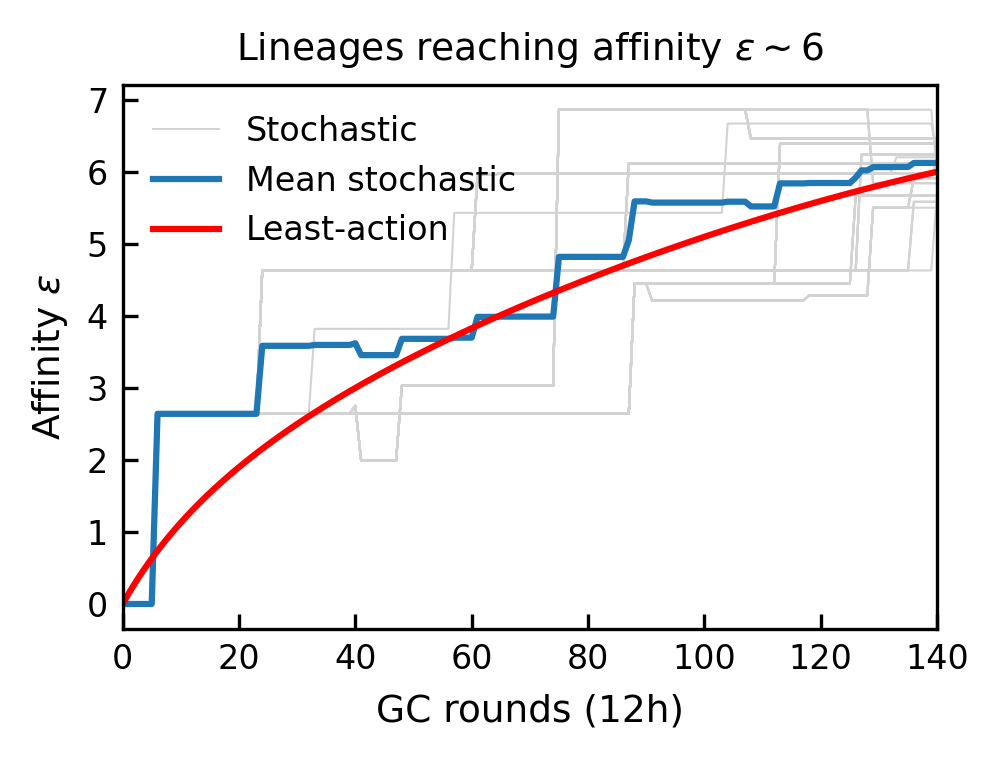

In [36]:
import numpy as np
from numpy.random import default_rng
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib import rcParams

# --------------------- biological / model parameters -------------------
mu_M = -0.8
sigma_M = 1.09
S_mat = None  # defined later

mu = 0.001 * 3 * 40
p_sil = 0.5 * (mu) + (1 - mu)
p_let = 0.3 * (mu)
p_aa = 0.2 * (mu)
E_a = np.log(40)
T_steps = 140
kBT = 1
N_i = 2500
N_max = 2500
mu_i = 0.0
sigma_i = 0.001
p_diff = 0.10
c = 170

# -------------------------- helper functions ---------------------------
def energies(pop: np.ndarray, S_mat: np.ndarray) -> np.ndarray:
    """Compute energies for every cell and every antigen."""
    return pop @ S_mat

def P_Ag(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
    """Antigen-binding survival gate."""
    exp_term = np.exp((eps - E_a) / kBT)
    numer = (exp_term * C_vec).sum(axis=1)
    return numer / (1.0 + numer)

def P_T(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
    """T-cell-help survival gate."""
    C_tot = C_vec.sum()
    eE = np.exp(eps / kBT)
    Phi = (eE * C_vec).sum(axis=1)
    Phi_bar = Phi.mean()
    if C_tot == 0: return np.zeros_like(Phi)
    return Phi / (Phi + Phi_bar / C_tot)

# ----------------------- one maturation round --------------------------
def gc_round(pop: np.ndarray,
             ids: np.ndarray,
             next_uid: int,
             S_mat: np.ndarray,
             C_vec: np.ndarray,
             rng: np.random.Generator):
    """
    Advance the cycling population by one GC round, tracking IDs.
    
    Returns:
        pop: New population vectors
        ids: New population IDs
        parent_ids: The parent ID for each cell in the new population
        next_uid: Updated global ID counter
        mem_data: Tuple of (mem_pop, mem_ids, mem_parent_ids)
    """
    # 1. Duplication (Tracking Lineage) -------------------------------
    # Parents become the parent_ids for the next generation
    n_parents = pop.shape[0]
    
    # Repeat phenotypes
    pop = np.repeat(pop, 2, axis=0)
    
    # The 'ids' of the current step become 'parent_ids' of the next step
    parent_ids = np.repeat(ids, 2)
    
    # Generate fresh unique IDs for the new daughter cells
    ids = np.arange(next_uid, next_uid + 2 * n_parents, dtype=np.int64)
    next_uid += 2 * n_parents

    # 2. Somatic hyper-mutation ---------------------------------------
    N_cells = pop.shape[0]
    fate = rng.choice(["let", "aa", "sil"], size=N_cells, p=[p_let, p_aa, p_sil])

    alive_mask = fate != "let"
    aa_mask = fate == "aa"
    n_aa = aa_mask.sum()

    if n_aa:
        idx_sites = rng.integers(0, pop.shape[1], size=n_aa)
        delta_h = rng.normal(mu_M, sigma_M, size=n_aa)
        pop[aa_mask, idx_sites] = pop[aa_mask, idx_sites] + delta_h

    # Apply lethal filter to all parallel arrays
    pop = pop[alive_mask]
    ids = ids[alive_mask]
    parent_ids = parent_ids[alive_mask]
    
    if pop.size == 0:
        return pop, ids, parent_ids, next_uid, (np.empty((0, pop.shape[1])), np.array([]), np.array([]))

    # 3. Antigen-binding gate -----------------------------------------
    eps = energies(pop, S_mat)
    P_ag = P_Ag(eps, C_vec)
    survive = rng.random(size=P_ag.size) < P_ag
    
    pop = pop[survive]
    ids = ids[survive]
    parent_ids = parent_ids[survive]
    eps = eps[survive]
    
    if pop.size == 0:
        return pop, ids, parent_ids, next_uid, (np.empty((0, S_mat.shape[0])), np.array([]), np.array([]))

    # 4. T-cell-help gate ---------------------------------------------
    P_t = P_T(eps, C_vec)
    survive = rng.random(size=P_t.size) < P_t
    
    pop = pop[survive]
    ids = ids[survive]
    parent_ids = parent_ids[survive]
    
    if pop.size == 0:
        return pop, ids, parent_ids, next_uid, (np.empty((0, S_mat.shape[0])), np.array([]), np.array([]))

    # 5. Differentiation ----------------------------------------------
    diff_mask = rng.random(size=pop.shape[0]) < p_diff
    
    # Extract memory cells
    mem_pop = pop[diff_mask]
    mem_ids = ids[diff_mask]
    mem_parent_ids = parent_ids[diff_mask]
    
    # Keep cycling cells
    pop = pop[~diff_mask]
    ids = ids[~diff_mask]
    parent_ids = parent_ids[~diff_mask]

    return pop, ids, parent_ids, next_uid, (mem_pop, mem_ids, mem_parent_ids)

# ---------------------- full GC simulation driver ----------------------
def simulate_gc_with_ancestry(rounds: int,
                              S_mat: np.ndarray,
                              N_init: int = N_i,
                              N_max: int = N_max,
                              C_schedule = lambda r: np.array([c]),
                              mu_init: float = mu_i,
                              sigma_init: float = sigma_i,
                              seed: int | None = None):
    """
    Simulates GC and stores ID and Parent_ID to reconstruction lineages.
    """
    rng = default_rng(seed)
    N_h = S_mat.shape[0]

    # Initialize
    pop = rng.normal(mu_init, sigma_init, size=(N_init, N_h))
    
    # Assign initial IDs (0 to N_init-1)
    # Parent ID -1 indicates "Founder" (start of simulation)
    ids = np.arange(N_init, dtype=np.int64)
    parent_ids = np.full(N_init, -1, dtype=np.int64)
    next_uid = N_init

    # History will store dictionaries now
    history = []
    
    # Store state 0
    history.append({
        'pop': pop.copy(),
        'ids': ids.copy(),
        'parent_ids': parent_ids.copy()
    })

    for r in range(rounds):
        C_vec = np.asarray(C_schedule(), dtype=float)
        
        # Run round
        pop, ids, parent_ids, next_uid, _mem = gc_round(
            pop, ids, next_uid, S_mat, C_vec, rng
        )

        # Population Cap (Resampling)
        if pop.shape[0] > N_max:
            keep_idx = rng.choice(pop.shape[0], N_max, replace=False)
            pop = pop[keep_idx]
            ids = ids[keep_idx]
            parent_ids = parent_ids[keep_idx]

        history.append({
            'pop': pop.copy(),
            'ids': ids.copy(),
            'parent_ids': parent_ids.copy()
        })
        
        if pop.shape[0] == 0:
            break

    return history

# ---------------------- Lineage Reconstruction ----------------------
def trace_lineages(history, target_indices_at_end):
    """
    Reconstructs trajectories for specific cells found in the last step.
    
    Parameters
    ----------
    history : list of dicts
        The output from simulate_gc_with_ancestry.
    target_indices_at_end : array-like
        Indices in the *last* history frame of the cells you want to trace.
        
    Returns
    -------
    trajectories : list of numpy arrays
        A list where each element is an array of shape (T+1, N_h)
        representing the path of a single lineage.
    """
    if not history:
        return []

    # Get the last frame
    final_step = len(history) - 1
    last_frame = history[final_step]
    
    # These are the IDs we want to trace back
    current_ids_to_trace = last_frame['ids'][target_indices_at_end]
    
    # Initialize storage for paths: Dictionary mapping Final_ID -> List of vectors
    # We will trace backwards using IDs
    
    # Map: Final_Unique_ID -> Current_Ancestor_ID
    active_traces = {uid: uid for uid in current_ids_to_trace}
    
    # Storage: Final_Unique_ID -> List of h vectors
    results = {uid: [] for uid in current_ids_to_trace}
    
    for t in range(final_step, -1, -1):
        frame = history[t]
        
        # Create lookup for this frame: ID -> (Index, Parent_ID, Vector)
        # This is O(N) per frame.
        frame_lookup = {uid: (i, pid, vec) 
                       for i, (uid, pid, vec) 
                       in enumerate(zip(frame['ids'], frame['parent_ids'], frame['pop']))}
        
        for final_uid, ancestor_id in list(active_traces.items()):
            if ancestor_id in frame_lookup:
                _, parent_id, vector = frame_lookup[ancestor_id]
                results[final_uid].append(vector)
                
                # Step back: looking for parent in previous frame
                if parent_id != -1:
                    active_traces[final_uid] = parent_id
                else:
                    # Reached root
                    del active_traces[final_uid]
            else:
                # Should not happen in a unbroken chain
                del active_traces[final_uid]
                
    # Reverse lists to get time 0 -> T
    trajectories = []
    for uid in current_ids_to_trace:
        traj = np.array(results[uid][::-1])
        trajectories.append(traj)
        
    return trajectories

# ---------------------- Run & Plot Logic ----------------------

# Setup Single Antigen
S_mat = np.array([[1]])
def C_schedule(): return np.array([c])

# Run Simulation
print("Simulating...")
history = simulate_gc_with_ancestry(
    rounds=T_steps,
    S_mat=S_mat,
    N_init=N_i,
    N_max=N_max,
    C_schedule=C_schedule,
    seed=1
)

# 1. Identify Target Cells in the Final Population
last_frame = history[-1]
final_pop = last_frame['pop']
final_energies = energies(final_pop, S_mat).flatten()

# Filter: Find indices where 5 <= h < 6
target_indices = np.where((final_energies >= 5.5) & (final_energies < 6.5))[0]

print(f"Simulation ended with {len(final_pop)} cells.")
print(f"Found {len(target_indices)} cells with 5 <= h < 6.")

# 2. Get Trajectories
trajectories = trace_lineages(history, target_indices)


# 3. Plotting using PRL-style settings provided
# --- PRL-style font and layout settings ------------------------------
rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "legend.fontsize": 8,
    "figure.figsize": (3.4, 2.6),  # ~8.6cm × 6.6cm
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

# --- Load trajectory from CSV ----------------------------------------
try:
    # Try loading the file if it exists
    h_sol = np.loadtxt("../multi Ag/trajectory_h_140.csv", delimiter=",")
    T = T_steps
    n_points = len(h_sol)
    t_sol = np.linspace(0, T, n_points)
except OSError:
    # Fallback if file not found (allows script to run without file)
    print("CSV file '../multi Ag/trajectory_h_140.csv' not found. Skipping least-action trajectory.")
    h_sol = None
    t_sol = None
    T = T_steps

# --- Prepare B-cell lineage trajectories ------------------------------
h1_by_round = defaultdict(list)
fig, ax = plt.subplots()
first = True

# Map existing 'trajectories' list to the logic structure requested
for traj in trajectories:
    h1 = traj.flatten() # 1D antigen assumption
    rounds = np.arange(len(h1))

    for t, h in zip(rounds, h1):
        h1_by_round[t].append(h)
    
    if first:
        ax.plot(rounds, h1, lw=0.5, color='lightgrey', label='Stochastic')
        first = False
    else:
        ax.plot(rounds, h1, lw=0.5, color='lightgrey')

# --- Plot mean trajectory in blue -------------------------------------
if h1_by_round:
    common_rounds = sorted(h1_by_round.keys())
    mean_h1 = [np.mean(h1_by_round[t]) for t in common_rounds]
    ax.plot(common_rounds, mean_h1, lw=1.5, color='C0', label='Mean stochastic')

# --- Plot least-action trajectory in red ------------------------------
if h_sol is not None:
    ax.plot(t_sol, h_sol, lw=1.5, color='red', label='Least-action')

# --- Final formatting -------------------------------------------------
t_max = T_steps
target = "5-6"
ax.set_xlim(0, t_max)
ax.set_xlabel("GC rounds (12h)")
ax.set_ylabel(r"Affinity $\epsilon$")
ax.legend(frameon=False, loc="upper left")
ax.set_title(r"Lineages reaching affinity $\epsilon\sim6$")
fig.tight_layout()
plt.show()

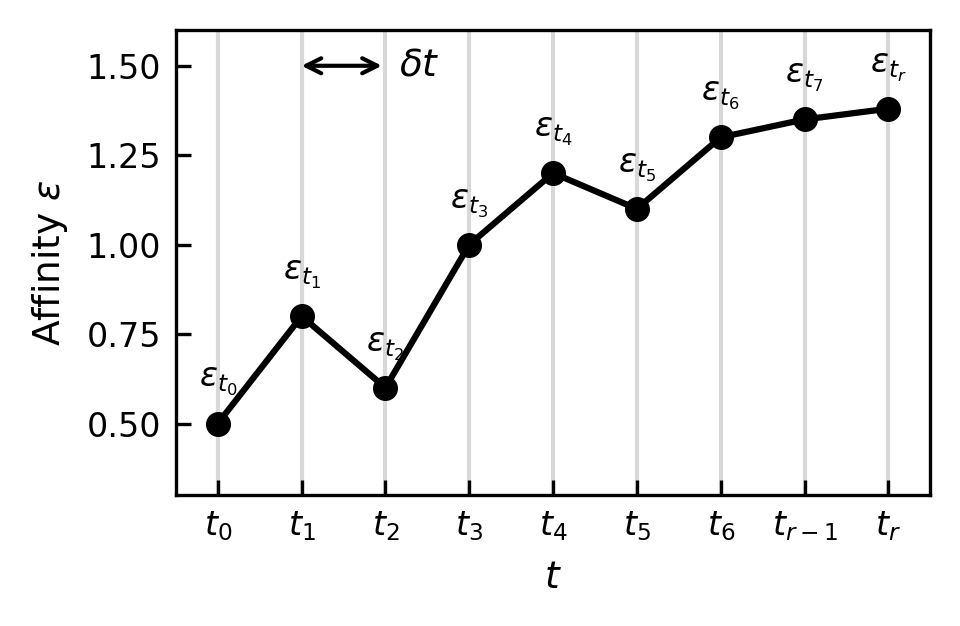

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# --- Sample data resembling schematic trajectory -------------------------
t = np.arange(9)
h = np.array([0.5, 0.8, 0.6, 1.0, 1.2, 1.1, 1.3, 1.35, 1.38])  # example h₁,t values

# --- Create plot ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(3.2, 2.2))  # PRL single column sizing

# Plot points and lines
ax.plot(t, h, 'k-', marker='o', markersize=5, linewidth=1.5)

# Vertical time ticks
for ti in t:
    ax.axvline(ti, color='grey', alpha=0.3, linestyle='-', zorder=0)

# Label each point with h_{1,t_i}
for i, (ti, hi) in enumerate(zip(t, h)):
    label = r"$\epsilon_{t_{%d}}$" % i if i not in [0, len(t)-1] else (
        r"$\epsilon_{t_0}$" if i == 0 else r"$\epsilon_{t_r}$")
    ax.text(ti, hi + 0.07, label, ha='center', va='bottom', fontsize=8)

# Time axis labels
ax.set_xticks(t)
xticklabels = [r"$t_0$", r"$t_1$", r"$t_2$", r"$t_3$", r"$t_4$", r"$t_5$", r"$t_6$", r"$t_{r-1}$", r"$t_r$"]
ax.set_xticklabels(xticklabels, rotation=0)

# Axes labels
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"Affinity $\epsilon$")

# Remove top/right spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# Delta t annotation
ax.annotate(r"$\delta t$",
            xy=(0.9, 1.5), xytext=(2.4, 1.5),
            arrowprops=dict(arrowstyle='<->', lw=1),
            ha='center', va='center', fontsize=9)

# Format
ax.tick_params(direction='in')
ax.set_xlim(-0.5, t[-1] + 0.5)
ax.set_ylim(0.3, 1.6)
fig.tight_layout()
plt.show()
